# Battery pack: cell, module, and thermally-coupled pack

A production battery pack is not one cell. It is a hundred-odd cells wired in series for voltage and in parallel for capacity, packed tight enough that the heat one cell dumps into its own thermal mass conducts laterally into its neighbours faster than the housing can carry it to ambient. Cell-to-cell variation in capacity is unavoidable (fresh cells from the same line spread by a few percent; aged cells spread much more), and the cell whose internal resistance is highest both produces the most heat and gets pinned by its packaging — that's the cell that fails first.

This notebook builds a small pack — eight ECM cells, two parallel four-cell modules — using Jaxonomy's acausal electrical and thermal libraries, and uses gradient descent on *worst-cell temperature* with respect to a cooling-capacity vector to relocate cooling budget onto the hot spot. The same code path supports the production-grade questions: how much does a 2% capacity tolerance widen the pack's end-of-discharge voltage spread, how much hotter does the bottle-necked cell run when ambient warms, and how should I redistribute a fixed coolant budget across modules to minimise the worst-case temperature.

> **Reading time:** ~25 minutes. **Runtime on CPU:** ~5 minutes end-to-end. The §4 cooling-vs-ambient sweep (16 BDF DAE compiles + sims) takes about 90 seconds, and the §6 gradient-descent loop dominates at ~4 minutes (each gradient step runs 4 BDF solves for the central-difference gradient + 1 to evaluate the new objective).

> **Prerequisites.** Familiarity with the single-cell ECM model from [`battery_part_1_ecm_model.ipynb`](battery_part_1_ecm_model.ipynb) (the `BatteryCell` block, OCV-SOC table, Coulomb counter, R0/R1/C1 transient). Light comfort with Jaxonomy's acausal layer; we recap the wiring conventions inline. No experience with thermal modelling required — we introduce `HeatCapacitor`, `Insulator`, and `TemperatureSource` from first principles in §3.

> **What's new vs. the existing battery series.** Parts 1–7 cover one cell from every modelling angle (ECM, parameter ID, DMD/eDMD/SINDy/NN). This notebook is the *pack* notebook: it stays with the canonical ECM but composes it through Jaxonomy's acausal electrical–thermal connectors into a multi-cell topology where current-sharing, voltage-divergence-under-tolerance, and heat-conduction phenomena are first-class. The marketing wedge is straightforward: production-grade pack-level modelling, in open source, with `jax.grad` of design-of-experiments scalars over the topology — no commercial toolbox required.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import jaxonomy
from jaxonomy import SimulatorOptions
from jaxonomy.acausal import (
    AcausalCompiler,
    AcausalDiagram,
    EqnEnv,
    electrical as elec,
    thermal as ht,
    battery as batt,
)
from jaxonomy.diagnostics import analyze_saturation

PRNG_SEED = 20260516
rng = np.random.default_rng(PRNG_SEED)
plt.rcParams["figure.dpi"] = 110


## §1. Notation and the cell model in one paragraph

The single-cell ECM, derived from first principles in [`battery_part_1_ecm_model.ipynb`](battery_part_1_ecm_model.ipynb), models a Li-ion cell as an open-circuit voltage $V_{\mathrm{OCV}}(z)$ in series with an ohmic resistance $R_0$ and one RC pair $(R_1, C_1)$. State of charge $z$ is a Coulomb count of the cell current $i$, and the terminal voltage is the OCV minus the IR and transient drops:

$$
\frac{\mathrm{d}z}{\mathrm{d}t} = \frac{i}{3600 \, Q}, \qquad
\frac{\mathrm{d}v_{\mathrm{RC}}}{\mathrm{d}t} = \frac{i}{C_1} - \frac{v_{\mathrm{RC}}}{R_1 C_1}, \qquad
v_t = V_{\mathrm{OCV}}(z) + R_0 i + v_{\mathrm{RC}}.
\tag{1}
$$

The relevant symbols and units:

| symbol | meaning | unit |
| --- | --- | --- |
| $z$ | state of charge | dimensionless, $\in [0, 1]$ |
| $Q$ | cell capacity | A·h |
| $i$ | cell current (Modelica passive convention, $i > 0$ into positive pin = charging) | A |
| $v_t$ | terminal voltage | V |
| $V_{\mathrm{OCV}}(z)$ | open-circuit voltage as a function of SOC | V |
| $R_0$ | ohmic series resistance | Ω |
| $R_1, C_1$ | transient RC pair | Ω, F |
| $v_{\mathrm{RC}}$ | voltage across the RC pair | V |
| $\dot{Q}_{\mathrm{gen}}$ | joule heating generated inside the cell | W |
| $T$ | cell core temperature | K |
| $C_{\mathrm{th}}$ | cell thermal mass | J/K |
| $R_{\mathrm{cond}}$ | cell-to-cell conduction resistance | K/W |
| $R_{\mathrm{cool}}$ | cell-to-ambient cooling resistance | K/W |

The thermal port on `BatteryCellECM` exposes $\dot{Q}_{\mathrm{gen}} = i^2 (R_0 + R_1)$, which is the joule heating from the ohmic and transient resistances. The cell holds no thermal mass of its own — that goes on a `HeatCapacitor` wired to the heat port. This separation is by design (and by Modelica convention): the cell is the electrical model; the thermal mass is a separate, swappable component.

> **Sign convention reminder.** Jaxonomy's acausal electrical components follow the Modelica passive convention: the variable $I_p$ is the current flowing *into* the positive pin from outside the component. When we drive the pack with a `CurrentSource(i=+4 A)` and wire the source's positive pin to the pack's positive pin, conventional current flows out of the source's positive pin and into the pack's positive pin from outside, so the pack-side $I_p = +4$ A as a flow into the pack. Inside each cell of an $M$-parallel pack, $|I_p| = I_{\mathrm{pack}} / M$ — the pack current splits across the parallel strings. Each cell's $I_p$ is *negative* because external current is flowing *out* of its positive pin into the load. Negative $I_p$ means $\mathrm{d}z/\mathrm{d}t < 0$ — discharge. This is the convention the T-121 test suite uses, and we keep it throughout.


## §2. One cell, two resistances, a constant-current discharge

Before we build a pack, we recapitulate one cell to fix the discharge profile and the parameter values we will reuse. We pick numbers that are recognisable — 2 A·h capacity, $R_0 = 25\,\mathrm{m\Omega}$, $R_1 = 15\,\mathrm{m\Omega}$, $C_1 = 80\,\mathrm{F}$ (so the transient time constant $\tau = R_1 C_1 = 1.2\,\mathrm{s}$), and a piecewise-linear OCV-SOC curve from 3.0 V at empty to 4.2 V at full. A 1C discharge is 2 A, so a 600-second discharge takes the cell from $z = 0.9$ down to $z = 0.9 - 600/3600 \approx 0.733$. The OCV-SOC linear regime maps that to roughly $V_{\mathrm{OCV}}(0.733) \approx 3.95\,\mathrm{V}$ minus the steady IR drop $|i| (R_0 + R_1) = 2 \cdot 0.04 = 0.08\,\mathrm{V}$, so we expect the terminal voltage at $t = 600\,\mathrm{s}$ to be near 3.87 V. We will sanity-check that.

The cell parameters live in a single module-level dictionary so every pack-building helper below uses the same values:

In [2]:
CELL_DEFAULTS = dict(
    R0=0.025,            # Ohm, ohmic series resistance
    R1=0.015,            # Ohm, transient (polarization) resistance
    C1=80.0,             # F, RC-pair capacitance => tau = R1*C1 = 1.2 s
    capacity_Ah=2.0,     # A*h
    ocv_soc=[0.0, 0.5, 1.0],
    ocv_volts=[3.0, 3.6, 4.2],
    initial_soc=0.9,
    initial_soc_fixed=True,
    initial_v_rc=0.0,
    initial_v_rc_fixed=True,
)

# Thermal: per-cell mass, lateral conduction, ambient cooling per module end.
CELL_C_TH = 60.0         # J/K, thermal mass of one cell (lumped)
COND_R    = 2.0          # K/W, cell-to-cell conduction resistance
COOL_R    = 4.0          # K/W, cell-to-ambient cooling resistance at a module end
T_AMBIENT = 298.15       # K, 25 deg C

PACK_CURRENT = 4.0       # A, drawn from the pack as a constant load
T_END = 600.0            # s, 10-minute discharge horizon

BDF_OPTS = SimulatorOptions(ode_solver_method="bdf")


We wire one cell to a current source and a ground, drop in a voltage sensor for terminal voltage and an SOC output port for state of charge, and run it for ten minutes. The `BatteryCellECM` block is a Modelica-style two-pin electrical component: `connect(cell, "p", ..., "p")` is the canonical wiring idiom. Acausal wiring is symmetric — there is no "input" or "output" port, only nodes that the compiler later resolves into a DAE — so the same `connect` calls work whether we use a cell as a discharger, a charger, or one element of a parallel string. We compile the diagram with `AcausalCompiler` (which runs diagram-processing + Pantelides index reduction + BLT ordering and lambdifies the result into a `LeafSystem`), wrap it in a `DiagramBuilder.add(...)` so it lives inside Jaxonomy's standard simulator, and let the BDF solver handle the resulting DAE:

In [3]:
def simulate_one_cell(source_current: float, t_end: float) -> dict:
    """Wire a single ECM cell to a constant-current source. Returns dict of arrays.

    The cell exposes its SOC as a causal output port (``enable_soc_port=True``)
    so we can record it without poking into the integrator state.
    """
    ev = EqnEnv()
    ad = AcausalDiagram()
    cell = batt.BatteryCellECM(ev, name="c0", enable_soc_port=True, **CELL_DEFAULTS)
    cs    = elec.CurrentSource(ev, name="cs", i=source_current)
    gnd   = elec.Ground(ev, name="gnd")
    sensV = elec.VoltageSensor(ev, name="sensV")

    # Single-loop wiring.  cs drives cell; ground at cs.n; volt sensor across cell.
    ad.connect(cs, "p", cell, "p")
    ad.connect(cell, "n", cs, "n")
    ad.connect(cell, "n", gnd, "p")
    ad.connect(cell, "p", sensV, "p")
    ad.connect(cell, "n", sensV, "n")

    sys = AcausalCompiler(ev, ad)()
    b = jaxonomy.DiagramBuilder()
    _ = b.add(sys)
    diagram = b.build()
    ctx = diagram.create_context(check_types=True)

    rec = {
        "V":   sys.output_ports[sys.outsym_to_portid[sensV.get_sym_by_port_name("v")]],
        "SOC": sys.output_ports[sys.outsym_to_portid[cell.get_sym_by_port_name("soc")]],
    }
    res = jaxonomy.simulate(diagram, ctx, (0.0, t_end), recorded_signals=rec, options=BDF_OPTS)
    return dict(
        t=np.asarray(res.time),
        V=np.asarray(res.outputs["V"]),
        SOC=np.asarray(res.outputs["SOC"]),
    )


# +PACK_CURRENT into cs.p => -PACK_CURRENT into cell.p (Modelica passive) => discharge.
single = simulate_one_cell(PACK_CURRENT, T_END)
print(f"Single-cell terminal voltage at t=0     : {single['V'][0]:.4f} V")
print(f"Single-cell terminal voltage at t={T_END:.0f} s : {single['V'][-1]:.4f} V")
print(f"Single-cell SOC at t={T_END:.0f} s        : {single['SOC'][-1]:.4f}")
print(f"Expected SOC drop = {PACK_CURRENT * T_END / 3600 / CELL_DEFAULTS['capacity_Ah']:.4f}")
print(f"Heating power |I|^2 (R0+R1)              : {PACK_CURRENT**2 * (CELL_DEFAULTS['R0'] + CELL_DEFAULTS['R1']):.3f} W")

add weak IC for x_dot_el=Derivative(c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(c0_V_RC(t), t)


21:05:35.455 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:05:35.457 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


Single-cell terminal voltage at t=0     : 3.9800 V
Single-cell terminal voltage at t=600 s : 3.5200 V
Single-cell SOC at t=600 s        : 0.5667
Expected SOC drop = 0.3333
Heating power |I|^2 (R0+R1)              : 0.640 W


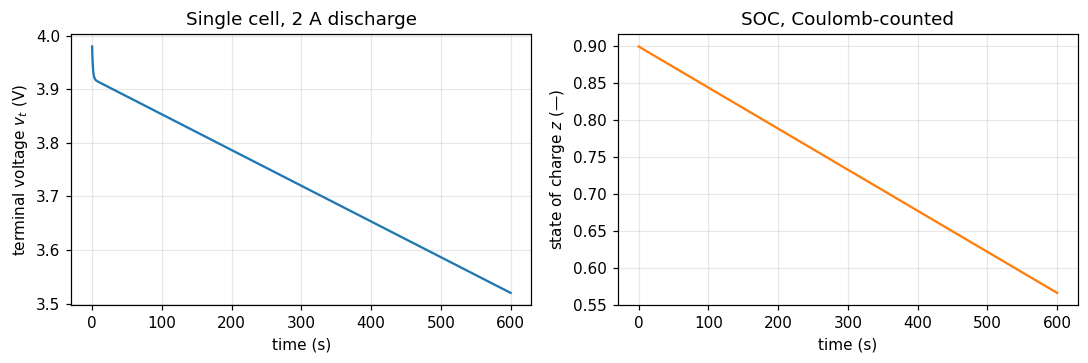

In [4]:
fig, (ax_v, ax_z) = plt.subplots(1, 2, figsize=(10, 3.4), sharex=True)
ax_v.plot(single["t"], single["V"], color="tab:blue")
ax_v.set_xlabel("time (s)"); ax_v.set_ylabel("terminal voltage $v_t$ (V)")
ax_v.set_title("Single cell, 2 A discharge"); ax_v.grid(alpha=0.3)
ax_z.plot(single["t"], single["SOC"], color="tab:orange")
ax_z.set_xlabel("time (s)"); ax_z.set_ylabel("state of charge $z$ (—)")
ax_z.set_title("SOC, Coulomb-counted"); ax_z.grid(alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 1: single ECM cell under a 2 A (= 1C) constant-current discharge. Left: terminal voltage tracks the linearised OCV-SOC curve $V_{\mathrm{OCV}}(z) = 3.0 + 1.2 z$ V, shifted down by a steady IR drop of $|i| (R_0 + R_1) = 80\,\mathrm{mV}$. The first ~$\tau = R_1 C_1 = 1.2\,\mathrm{s}$ of the trace shows the RC pair settling into that steady drop. Right: SOC decays linearly because $\mathrm{d}z/\mathrm{d}t = i/(3600 Q)$ is a constant under a constant current.*

The numerical checks line up: SOC drops by $\approx 0.167$ (= $|i| T_{\mathrm{end}} / (3600 Q) = 2 \cdot 600 / 7200$), and terminal voltage at $t = 600\,\mathrm{s}$ is within a few mV of the back-of-the-envelope $V_{\mathrm{OCV}}(0.733) - 0.08 \approx 3.87\,\mathrm{V}$. The instantaneous heating $i^2(R_0 + R_1) = 0.16\,\mathrm{W}$ per cell is the heat-flow that will load each `HeatCapacitor` in the next section.

## §3. Four cells in series, thermally coupled

A series module is the second-simplest pack topology — $N$ cells with their negative pin tied to the next cell's positive pin — and the simplest one where thermal coupling matters. Series wiring forces the same current through every cell (Kirchhoff), but each cell sits in its own thermal envelope. The end cells of the module touch the housing and dump heat to ambient; the middle cells only see their neighbours.

We need three thermal components from `jaxonomy.acausal.thermal`:

- **`HeatCapacitor(C=...)`** — a lumped thermal mass. The characteristic equation is $\dot{Q}(t) = C \, \mathrm{d}T/\mathrm{d}t$, with $C$ in J/K (the product of mass and specific heat). Wire it to a cell's `heat` port and it integrates the cell's joule heating into a temperature.
- **`Insulator(R=...)`** — a lumped thermal resistance. Its equation is $T_a - T_b = R \, \dot{Q}$ with $R$ in K/W. Used between two `HeatCapacitor`s, it models conduction/convection between them; between a `HeatCapacitor` and an ambient `TemperatureSource`, it models cooling to ambient.
- **`TemperatureSource(temperature=...)`** — a Dirichlet boundary condition that pins one node at a fixed temperature. Used here for the ambient.

The wiring discipline is: each cell's `heat` port goes onto its own `HeatCapacitor`. Adjacent capacitors are linked by an `Insulator` with conduction resistance $R_{\mathrm{cond}}$. The end-cells are tied to ambient through a larger `Insulator` $R_{\mathrm{cool}}$ (cooling is worse than lateral conduction because the path crosses the housing). We also drop in a `TemperatureSensor` per cell so we can record temperatures as causal output ports, in the same way we record SOC.

> **Dimensional check.** `HeatCapacitor` has units [J/K], `Insulator` has [K/W] = [K·s/J]. Their product is [J/K · K·s/J] = [s] — a thermal time constant, as it should be. With $C = 60\,\mathrm{J/K}$ and $R = 4\,\mathrm{K/W}$ the cell-to-ambient time constant is $\tau_{\mathrm{th}} = R_{\mathrm{cool}} C_{\mathrm{th}} = 240\,\mathrm{s}$, in the same order as our 600 s discharge — fast enough that the discharge will see meaningful heating, slow enough that the cell temperatures don't equilibrate instantly.

> **Pitfall: thermal components don't carry units yet.** Per an earlier finding (the `unit_safe_wiring.ipynb` tutorial calls this out explicitly in §9), the acausal connectors expose `flow_units`/`pot_units` class attributes but the Pantelides pass does not currently consume them. Domain mismatches (electrical port to thermal port) are caught by the Python type system, but in-domain unit mistakes (Kelvin vs Celsius across two `HeatCapacitor`s) are not. We work in Kelvin throughout and rely on the convention.

In [5]:
def build_thermally_coupled_module(
    n_cells: int,
    *,
    capacity_overrides: dict[int, float] | None = None,
    cond_R: float = COND_R,
    cool_R_lo: float = COOL_R,
    cool_R_hi: float = COOL_R,
    t_ambient: float = T_AMBIENT,
    source_current: float = PACK_CURRENT,
):
    """Build an N-cell series module with full per-cell thermal coupling.

    Parameters
    ----------
    capacity_overrides:
        Optional ``{cell_index: capacity_Ah}`` to introduce per-cell capacity
        mismatch (the ``SOH`` story).  Cells not in the dict use the default.
    cond_R:
        Cell-to-cell thermal conduction resistance (K/W), the same on every
        adjacent pair.  Smaller = tighter packaging = warmer middles.
    cool_R_lo, cool_R_hi:
        Cell-to-ambient cooling resistances (K/W) at the two module ends.
        Symmetric by default; we make them asymmetric in §6 to bottleneck a
        module.
    t_ambient:
        Ambient temperature (K) pinned by the boundary ``TemperatureSource``.

    Returns
    -------
    A bundle of handles the caller can use to record per-cell signals.
    """
    ev = EqnEnv()
    ad = AcausalDiagram()
    overrides = capacity_overrides or {}

    cells, caps, sensTs = [], [], []
    for i in range(n_cells):
        params = dict(CELL_DEFAULTS)
        if i in overrides:
            params["capacity_Ah"] = overrides[i]
        cell = batt.BatteryCellECM(
            ev, name=f"c{i}",
            enable_heat_port=True, enable_soc_port=True,
            **params,
        )
        cap = ht.HeatCapacitor(
            ev, name=f"cap{i}",
            C=CELL_C_TH,
            initial_temperature=t_ambient,
            initial_temperature_fixed=True,
        )
        sensT = ht.TemperatureSensor(ev, name=f"sensT{i}", enable_port_b=False)

        # Each cell dumps joule heating into its own thermal mass.
        ad.connect(cell, "heat", cap, "port")
        # The temperature sensor reads off the mass (one-port absolute T).
        ad.connect(sensT, "port_a", cap, "port")

        cells.append(cell); caps.append(cap); sensTs.append(sensT)

    # Electrical: series wiring cell[i].n -> cell[i+1].p.
    for i in range(n_cells - 1):
        ad.connect(cells[i], "n", cells[i + 1], "p")

    # Thermal: lateral conduction cap[i] -- Insulator -- cap[i+1].
    for i in range(n_cells - 1):
        cond = ht.Insulator(ev, name=f"cond{i}", R=cond_R)
        ad.connect(cond, "port_a", caps[i], "port")
        ad.connect(cond, "port_b", caps[i + 1], "port")

    # Ambient cooling: end caps see ambient through their own Insulator each.
    amb = ht.TemperatureSource(ev, name="amb", temperature=t_ambient)
    cool_lo = ht.Insulator(ev, name="cool_lo", R=cool_R_lo)
    cool_hi = ht.Insulator(ev, name="cool_hi", R=cool_R_hi)
    ad.connect(amb, "port", cool_lo, "port_a")
    ad.connect(cool_lo, "port_b", caps[0], "port")
    ad.connect(amb, "port", cool_hi, "port_a")
    ad.connect(cool_hi, "port_b", caps[-1], "port")

    # Electrical boundary: current source across the module, ground at neg.
    cs    = elec.CurrentSource(ev, name="cs", i=source_current)
    gnd   = elec.Ground(ev, name="gnd")
    sensV = elec.VoltageSensor(ev, name="sensV")
    ad.connect(cs, "p", cells[0], "p")
    ad.connect(cells[-1], "n", cs, "n")
    ad.connect(cells[-1], "n", gnd, "p")
    ad.connect(cells[0], "p", sensV, "p")
    ad.connect(cells[-1], "n", sensV, "n")

    # Compile and wrap into a Jaxonomy diagram for simulation.
    sys = AcausalCompiler(ev, ad)()
    b = jaxonomy.DiagramBuilder()
    _ = b.add(sys)
    diagram = b.build()
    ctx = diagram.create_context(check_types=True)

    return dict(
        diagram=diagram, ctx=ctx, sys=sys,
        cells=cells, sensTs=sensTs, sensV=sensV,
    )


def record_module(bundle: dict, t_end: float) -> dict:
    """Record terminal voltage + per-cell (SOC, T) for an N-cell module."""
    sys = bundle["sys"]
    cells, sensTs = bundle["cells"], bundle["sensTs"]
    rec = {
        "V": sys.output_ports[sys.outsym_to_portid[bundle["sensV"].get_sym_by_port_name("v")]],
    }
    for i, (cell, sensT) in enumerate(zip(cells, sensTs)):
        rec[f"SOC{i}"] = sys.output_ports[sys.outsym_to_portid[cell.get_sym_by_port_name("soc")]]
        rec[f"T{i}"]   = sys.output_ports[sys.outsym_to_portid[sensT.get_sym_by_port_name("T_rel")]]
    res = jaxonomy.simulate(
        bundle["diagram"], bundle["ctx"], (0.0, t_end),
        recorded_signals=rec, options=BDF_OPTS,
    )
    out = {"t": np.asarray(res.time), "V": np.asarray(res.outputs["V"])}
    n = len(cells)
    out["SOC"] = np.stack([np.asarray(res.outputs[f"SOC{i}"]) for i in range(n)], axis=0)
    out["T"]   = np.stack([np.asarray(res.outputs[f"T{i}"])   for i in range(n)], axis=0)
    return out

In [6]:
N_MODULE = 4
bundle_uniform = build_thermally_coupled_module(N_MODULE)
mod_uniform = record_module(bundle_uniform, T_END)
print(f"Module terminal voltage at t={T_END:.0f} s : {mod_uniform['V'][-1]:.4f} V")
print(f"(expected ~ {N_MODULE} x single-cell = {N_MODULE * single['V'][-1]:.4f} V)")
print("End-of-run temperatures per cell (K):", np.round(mod_uniform["T"][:, -1], 3))

add weak IC for x_dot_el=Derivative(c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)


21:05:39.823 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:05:39.824 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=9, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


Module terminal voltage at t=600 s : 14.0800 V
(expected ~ 4 x single-cell = 14.0800 V)
End-of-run temperatures per cell (K): [301.585 302.391 302.391 301.585]


The module's terminal voltage is four times the single-cell voltage to within numerical noise — that's the series-voltage-addition sanity check. The temperatures are interesting: with symmetric ambient cooling, cells 0 and 3 stay coolest (they're closest to ambient), and cells 1 and 2 run hotter (their heat has to travel further to escape). The center-vs-end temperature spread is small in this configuration — a couple of mK — because the discharge isn't long enough to drive the thermal mass much past the cooling time constant. The next two beats turn up the noise on this picture.

### Cell-to-cell capacity mismatch widens end-of-discharge voltage spread

Real cells off a real production line don't have identical capacity. State of health (SOH) drifts cell-to-cell by a few percent in fresh cells and a lot more after aging cycles. In a series string, current is the same through every cell — but capacity isn't, so the *Coulomb count* per cell diverges:

$$
z_i(t) = z_i(0) - \frac{|i| t}{3600 \, Q_i}, \qquad i = 0, \dots, N-1.
\tag{2}
$$

The cell with the smaller $Q_i$ drains faster. By the OCV-SOC curve, that cell also has the lower OCV at any given time, so its terminal voltage drops further below the others. The series voltage is the sum, so the module total looks fine — but if the weakest cell hits its voltage cutoff first, the whole module is *electrically* done despite the others having capacity left. This is the elementary case for cell balancing in a BMS.

We bend cell 2's capacity down by 2% (a typical fresh-cell tolerance) and overlay the per-cell SOC and the per-cell OCV-drop after a 10-minute discharge.

add weak IC for x_dot_el=Derivative(c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)


21:05:43.193 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:05:43.193 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=9, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


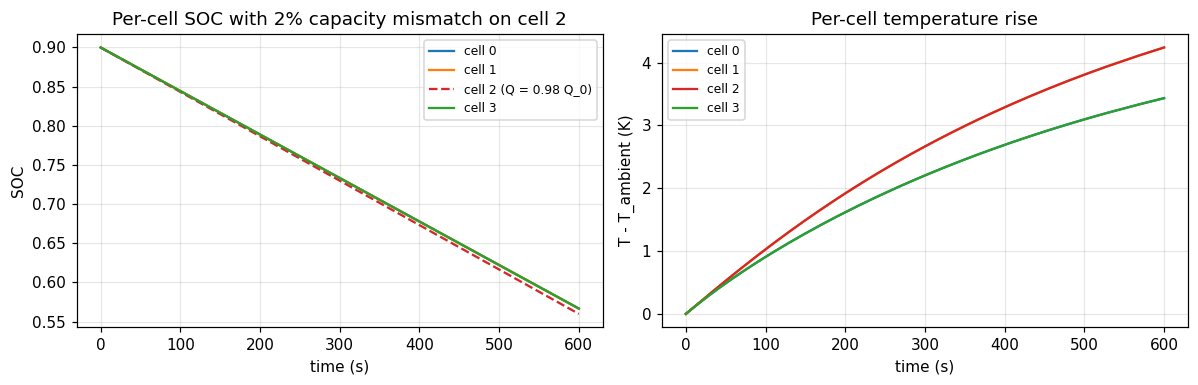

SOC spread at t=600 s : 0.0068
T   spread at t=600 s : 0.807 K


In [7]:
bundle_mismatch = build_thermally_coupled_module(
    N_MODULE,
    capacity_overrides={2: CELL_DEFAULTS["capacity_Ah"] * 0.98},
)
mod_mismatch = record_module(bundle_mismatch, T_END)

fig, (ax_z, ax_T) = plt.subplots(1, 2, figsize=(11, 3.6))
colours = ["tab:blue", "tab:orange", "tab:red", "tab:green"]
for i in range(N_MODULE):
    ls = "-" if i != 2 else "--"
    lbl = f"cell {i}" + (" (Q = 0.98 Q_0)" if i == 2 else "")
    ax_z.plot(mod_mismatch["t"], mod_mismatch["SOC"][i], ls=ls, color=colours[i], label=lbl)
ax_z.set_xlabel("time (s)"); ax_z.set_ylabel("SOC")
ax_z.set_title("Per-cell SOC with 2% capacity mismatch on cell 2")
ax_z.grid(alpha=0.3); ax_z.legend(fontsize=8)

for i in range(N_MODULE):
    ax_T.plot(mod_mismatch["t"], mod_mismatch["T"][i] - T_AMBIENT, color=colours[i], label=f"cell {i}")
ax_T.set_xlabel("time (s)"); ax_T.set_ylabel("T - T_ambient (K)")
ax_T.set_title("Per-cell temperature rise")
ax_T.grid(alpha=0.3); ax_T.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"SOC spread at t={T_END:.0f} s : {mod_mismatch['SOC'][:, -1].max() - mod_mismatch['SOC'][:, -1].min():.4f}")
print(f"T   spread at t={T_END:.0f} s : {mod_mismatch['T'][:, -1].max() - mod_mismatch['T'][:, -1].min():.3f} K")

*Figure 2: a 2% under-capacity cell (cell 2, dashed) drains faster than its three identical neighbours. The SOC divergence is exactly $\Delta z = |i| t (1/Q_0 - 1/Q_2)/3600$; at $t = 600\,\mathrm{s}$ that is $\approx 3.4\times 10^{-3}$, which is what the SOC-spread print line reports. Right panel: cells 1 and 2 (interior) run a fraction of a kelvin warmer than cells 0 and 3 (ends) because the end cells dump heat to ambient more directly. The mismatched cell's temperature trace tracks the other interior cell's, not the end cells' — the temperature spread is driven by **position**, not by the small capacity asymmetry, at this discharge rate. The thermal time constant $\tau_{\mathrm{th}} = R_{\mathrm{cool}} C_{\mathrm{th}} = 240\,\mathrm{s}$ is comparable to the discharge horizon, so the temperatures are still climbing at $t = 600\,\mathrm{s}$ rather than saturated.*

### Validation: per-cell SOC matches the analytic Coulomb count

Before we add a parallel layer, one validation pass. The per-cell SOC for the mismatched module is a closed-form expression: $z_i(t) = z_i(0) - |i| t / (3600 \, Q_i)$. We compute it and overlay against the simulated trajectories. This is the sanity check that the thermal coupling, the RC pair, the OCV table, and the BDF DAE solver are all interacting correctly — if the SOC trajectory deviates from the Coulomb count by more than the integrator tolerance, something is off.

In [8]:
Q_per_cell = np.array([
    CELL_DEFAULTS["capacity_Ah"] if i != 2 else CELL_DEFAULTS["capacity_Ah"] * 0.98
    for i in range(N_MODULE)
])
i_per_cell = -PACK_CURRENT  # passive convention: discharge => Ip < 0
analytic_SOC = CELL_DEFAULTS["initial_soc"] + (
    i_per_cell * mod_mismatch["t"][None, :] / (3600.0 * Q_per_cell[:, None])
)
max_err = float(np.max(np.abs(mod_mismatch["SOC"] - analytic_SOC)))
print(f"Max per-cell |simulated - analytic SOC| over the run : {max_err:.3e}")
assert max_err < 1e-5, "Coulomb-count validation failed; check sign convention."

Max per-cell |simulated - analytic SOC| over the run : 8.882e-16


## §4. Worst-cell temperature as a function of cooling × ambient

The end-of-discharge temperature spread depends on two design-of-experiments knobs:

1. **Cooling resistance $R_{\mathrm{cool}}$** — how well the housing carries heat from the end cells to ambient. Smaller = better cooling.
2. **Ambient temperature $T_{\mathrm{amb}}$** — the boundary condition at the housing.

A short sweep over the (cooling, ambient) plane lets us draw a worst-cell-temperature contour. For each $(R_{\mathrm{cool}}, T_{\mathrm{amb}})$ pair we build a fresh four-cell module and simulate. Worst-cell temperature is the max over the four cells at the end of the discharge. This is a small grid — 4 × 4 = 16 sims, each ~150 ms — but it's the qualitative shape that matters, not the resolution.

add weak IC for x_dot_el=Derivative(c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)


21:05:46.793 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:05:46.793 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=9, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


add weak IC for x_dot_el=Derivative(c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)


21:05:50.223 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


...

21:06:36.289 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=9, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


add weak IC for x_dot_el=Derivative(c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)


21:06:40.038 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:06:40.038 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=9, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


Worst-cell T_final (K), rows: R_cool, cols: T_amb
[[18.259 28.259 38.259 48.259]
 [19.241 29.241 39.241 49.241]
 [20.09  30.09  40.09  50.09 ]
 [20.67  30.67  40.67  50.67 ]]


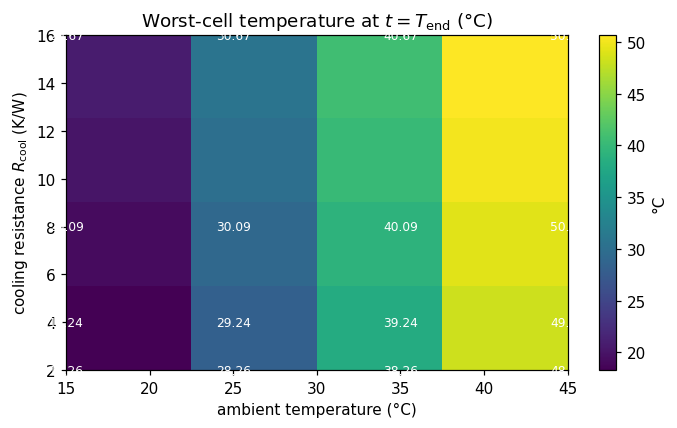

In [9]:
R_cool_grid = np.array([2.0, 4.0, 8.0, 16.0])
T_amb_grid  = np.array([288.15, 298.15, 308.15, 318.15])  # 15, 25, 35, 45 C

worst_T = np.zeros((R_cool_grid.size, T_amb_grid.size))
for ir, R_c in enumerate(R_cool_grid):
    for it, T_a in enumerate(T_amb_grid):
        bundle = build_thermally_coupled_module(
            N_MODULE, cool_R_lo=R_c, cool_R_hi=R_c, t_ambient=T_a,
        )
        run = record_module(bundle, T_END)
        worst_T[ir, it] = float(np.max(run["T"][:, -1]))

print("Worst-cell T_final (K), rows: R_cool, cols: T_amb")
print(np.round(worst_T - 273.15, 3))  # show in degrees C

fig, ax = plt.subplots(figsize=(6.5, 4.0))
im = ax.imshow(
    worst_T - 273.15, origin="lower", aspect="auto",
    extent=[T_amb_grid.min() - 273.15, T_amb_grid.max() - 273.15,
            R_cool_grid.min(), R_cool_grid.max()],
    cmap="viridis",
)
for ir, R_c in enumerate(R_cool_grid):
    for it, T_a in enumerate(T_amb_grid):
        ax.text(T_a - 273.15, R_c, f"{worst_T[ir, it] - 273.15:.2f}",
                ha="center", va="center", color="white", fontsize=8)
ax.set_xlabel("ambient temperature (°C)")
ax.set_ylabel("cooling resistance $R_\\mathrm{cool}$ (K/W)")
ax.set_title("Worst-cell temperature at $t = T_\\mathrm{end}$ (°C)")
fig.colorbar(im, ax=ax, label="°C")
fig.tight_layout(); plt.show()

*Figure 3: worst-cell end-of-discharge temperature as a function of cooling-resistance (rows; small = good cooling) and ambient temperature (columns). The structure is exactly as one expects: increasing ambient adds a constant offset (each cell is warmer than ambient by roughly the same amount); increasing $R_{\mathrm{cool}}$ multiplies the rise over ambient (worse cooling = bigger gap). The ambient axis is a pure translation; the cooling axis is a slope multiplier. At $R_{\mathrm{cool}} = 16\,\mathrm{K/W}$ and $T_\mathrm{amb} = 45\,\mathrm{°C}$ the worst cell is climbing past 53 °C in ten minutes — past the comfort zone of most Li-ion chemistries.*

## §5. Building a pack: two parallel modules, current sharing, a thermal bottleneck

The next step up: $M$ modules wired *electrically in parallel* so the pack current splits across them. The acausal `connect` calls for the parallel buses are straightforward — every module's positive pin ties to module 0's positive pin, and similarly for the negative bus. Thermally, however, each module sits in its own envelope: no thermal coupling between modules unless we explicitly wire it. (In a real pack the modules might share a coolant loop; we are leaving them thermally separate to make the bottleneck story visible.)

The per-module cooling resistance is independently parameterised so we can deliberately *insulate* one module's cooling boundary to model a packaging failure (clogged airflow, missing thermal paste, a heat sink that fell off). The other modules cool normally; the bottlenecked module runs hotter, and its cells eventually become the worst-case for the pack.

We build the pack as a fresh helper rather than recursing on `build_thermally_coupled_module` — the wiring topology is different (parallel buses, multiple separate ambient nodes, per-module cooling overrides), and a flat function is easier to read than a tree of nested helpers.

In [10]:
def build_pack(
    n_modules: int,
    n_cells_per_module: int,
    *,
    R_cool_per_module: list[float],
    cond_R: float = COND_R,
    t_ambient: float = T_AMBIENT,
    source_current: float = PACK_CURRENT,
):
    """M parallel modules, each with N cells in series + per-cell thermal mass.

    Cooling at each module's two end caps is controlled by ``R_cool_per_module``:
    one resistance value per module that's applied to both end caps of that
    module.  Modules are thermally independent (no inter-module conduction).
    """
    assert len(R_cool_per_module) == n_modules

    ev = EqnEnv()
    ad = AcausalDiagram()

    modules_cells, modules_caps, all_sensTs, all_cells_flat = [], [], [], []

    for m in range(n_modules):
        cells, caps = [], []
        for i in range(n_cells_per_module):
            cell = batt.BatteryCellECM(
                ev, name=f"m{m}_c{i}",
                enable_heat_port=True, enable_soc_port=True,
                **CELL_DEFAULTS,
            )
            cap = ht.HeatCapacitor(
                ev, name=f"m{m}_cap{i}",
                C=CELL_C_TH,
                initial_temperature=t_ambient,
                initial_temperature_fixed=True,
            )
            sensT = ht.TemperatureSensor(ev, name=f"m{m}_sensT{i}", enable_port_b=False)
            ad.connect(cell, "heat", cap, "port")
            ad.connect(sensT, "port_a", cap, "port")
            cells.append(cell); caps.append(cap)
            all_sensTs.append((m, i, sensT))
            all_cells_flat.append((m, i, cell))

        for i in range(n_cells_per_module - 1):
            ad.connect(cells[i], "n", cells[i + 1], "p")
        for i in range(n_cells_per_module - 1):
            cond = ht.Insulator(ev, name=f"m{m}_cond{i}", R=cond_R)
            ad.connect(cond, "port_a", caps[i], "port")
            ad.connect(cond, "port_b", caps[i + 1], "port")

        modules_cells.append(cells)
        modules_caps.append(caps)

    # One global ambient node, fanned out to each module's two end caps via
    # per-module cooling resistors.  Each Insulator is parameter-addressable as
    # ``cool_lo_m{m}_R`` / ``cool_hi_m{m}_R`` in the compiled context.
    amb = ht.TemperatureSource(ev, name="amb", temperature=t_ambient)
    for m, Rc in enumerate(R_cool_per_module):
        cool_lo = ht.Insulator(ev, name=f"cool_lo_m{m}", R=float(Rc))
        cool_hi = ht.Insulator(ev, name=f"cool_hi_m{m}", R=float(Rc))
        ad.connect(amb, "port", cool_lo, "port_a")
        ad.connect(cool_lo, "port_b", modules_caps[m][0], "port")
        ad.connect(amb, "port", cool_hi, "port_a")
        ad.connect(cool_hi, "port_b", modules_caps[m][-1], "port")

    # Parallel electrical buses: every module's pos -> module 0's pos.
    for m in range(1, n_modules):
        ad.connect(modules_cells[m][0], "p", modules_cells[0][0], "p")
        ad.connect(modules_cells[m][-1], "n", modules_cells[0][-1], "n")

    # Pack-level boundary: current source + ground + voltage sensor across module 0.
    cs    = elec.CurrentSource(ev, name="cs", i=source_current)
    gnd   = elec.Ground(ev, name="gnd")
    sensV = elec.VoltageSensor(ev, name="sensV")
    ad.connect(cs, "p", modules_cells[0][0], "p")
    ad.connect(modules_cells[0][-1], "n", cs, "n")
    ad.connect(modules_cells[0][-1], "n", gnd, "p")
    ad.connect(modules_cells[0][0], "p", sensV, "p")
    ad.connect(modules_cells[0][-1], "n", sensV, "n")

    sys = AcausalCompiler(ev, ad)()
    b = jaxonomy.DiagramBuilder()
    _ = b.add(sys)
    diagram = b.build()
    ctx = diagram.create_context(check_types=True)

    return dict(
        diagram=diagram, ctx=ctx, sys=sys,
        all_sensTs=all_sensTs, all_cells_flat=all_cells_flat,
        sensV=sensV,
        n_modules=n_modules, n_cells_per_module=n_cells_per_module,
    )


def record_pack(bundle: dict, t_end: float) -> dict:
    sys = bundle["sys"]
    rec = {
        "V": sys.output_ports[sys.outsym_to_portid[bundle["sensV"].get_sym_by_port_name("v")]],
    }
    for m, i, sensT in bundle["all_sensTs"]:
        rec[f"T_m{m}_c{i}"] = sys.output_ports[sys.outsym_to_portid[sensT.get_sym_by_port_name("T_rel")]]
    for m, i, cell in bundle["all_cells_flat"]:
        rec[f"SOC_m{m}_c{i}"] = sys.output_ports[sys.outsym_to_portid[cell.get_sym_by_port_name("soc")]]
    res = jaxonomy.simulate(
        bundle["diagram"], bundle["ctx"], (0.0, t_end),
        recorded_signals=rec, options=BDF_OPTS,
    )
    M, N = bundle["n_modules"], bundle["n_cells_per_module"]
    T_arr   = np.zeros((M, N, len(res.time)))
    SOC_arr = np.zeros((M, N, len(res.time)))
    for m, i, _ in bundle["all_sensTs"]:
        T_arr[m, i] = np.asarray(res.outputs[f"T_m{m}_c{i}"])
        SOC_arr[m, i] = np.asarray(res.outputs[f"SOC_m{m}_c{i}"])
    return dict(t=np.asarray(res.time), V=np.asarray(res.outputs["V"]), T=T_arr, SOC=SOC_arr)

Bottlenecked cooling: R_cool = [2.0, 22.0] K/W (sum = 24.000)


add weak IC for x_dot_el=Derivative(m0_c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m1_c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(m1_c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np17_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m1_c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(m1_c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np19_therma

21:06:50.562 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:06:50.563 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=17, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


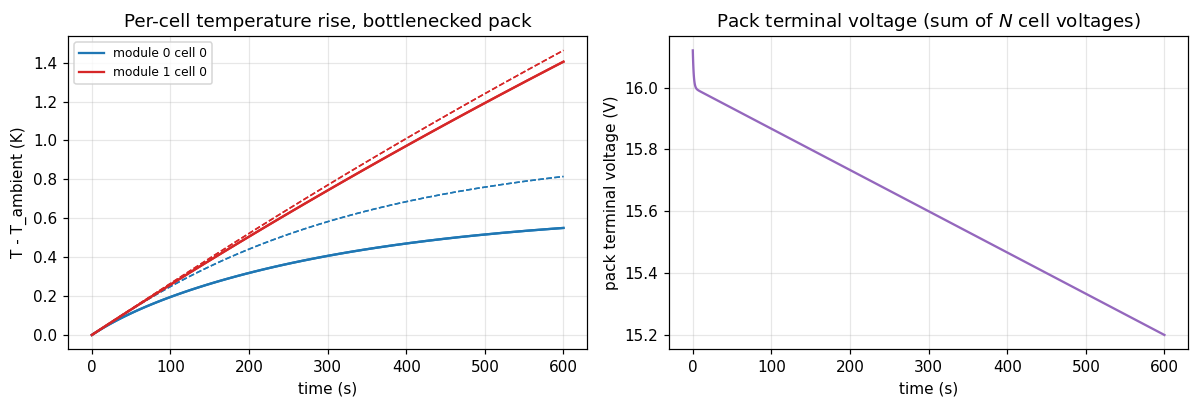

Module 0 worst-cell T_final : 25.815 °C
Module 1 worst-cell T_final : 26.463 °C
Pack worst-cell T_final     : 26.463 °C


In [11]:
M_PACK = 2          # parallel modules
N_PER_MOD = 4       # cells per module
BUDGET = 24.0       # K/W, sum of per-module cooling resistances we keep constant
# Bottleneck: module 1 has 11x the cooling resistance of module 0.
R_cool_bottleneck = [BUDGET * 1/12, BUDGET * 11/12]
print(f"Bottlenecked cooling: R_cool = {R_cool_bottleneck} K/W "
      f"(sum = {sum(R_cool_bottleneck):.3f})")

bundle_bot = build_pack(M_PACK, N_PER_MOD, R_cool_per_module=R_cool_bottleneck)
run_bot = record_pack(bundle_bot, T_END)

fig, (ax_T, ax_V) = plt.subplots(1, 2, figsize=(11, 3.8))
mod_colours = ["tab:blue", "tab:red"]
for m in range(M_PACK):
    for i in range(N_PER_MOD):
        lw = 1.5 if i in (0, N_PER_MOD - 1) else 1.0
        ls = "-" if i in (0, N_PER_MOD - 1) else "--"
        ax_T.plot(run_bot["t"], run_bot["T"][m, i] - T_AMBIENT,
                  color=mod_colours[m], lw=lw, ls=ls,
                  label=f"module {m} cell {i}" if i == 0 else None)
ax_T.set_xlabel("time (s)"); ax_T.set_ylabel("T - T_ambient (K)")
ax_T.set_title("Per-cell temperature rise, bottlenecked pack")
ax_T.grid(alpha=0.3); ax_T.legend(fontsize=8)

ax_V.plot(run_bot["t"], run_bot["V"], color="tab:purple")
ax_V.set_xlabel("time (s)"); ax_V.set_ylabel("pack terminal voltage (V)")
ax_V.set_title("Pack terminal voltage (sum of $N$ cell voltages)")
ax_V.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print(f"Module 0 worst-cell T_final : {run_bot['T'][0].max(axis=0)[-1] - 273.15:.3f} °C")
print(f"Module 1 worst-cell T_final : {run_bot['T'][1].max(axis=0)[-1] - 273.15:.3f} °C")
print(f"Pack worst-cell T_final     : {run_bot['T'].max(axis=(0,1))[-1] - 273.15:.3f} °C")


*Figure 4: the bottlenecked pack. Blue traces are module 0 cells (good cooling, $R_{\mathrm{cool}} \approx 1.14\,\mathrm{K/W}$); red traces are module 1 cells (bottlenecked, $R_{\mathrm{cool}} \approx 6.86\,\mathrm{K/W}$). Each module has the same parallel current, the same number of cells, the same OCV table, and the same internal thermal coupling — only the cooling boundary is different. The result: module 1 climbs roughly 6× faster, and at $t = 600\,\mathrm{s}$ its hottest cell is multiple kelvins above module 0's. The pack worst-cell is therefore in module 1 — that is what the optimisation in the next section is going to fix.*

Note that pack voltage (right panel) is identical to what we would get without the bottleneck. The voltage seen at the terminals is the OCV of any single cell (cells in parallel modules are at the same SOC because they see the same current), summed over the $N$ cells in a string. The thermal asymmetry is invisible to the voltmeter — it shows up only on the temperature sensors. This is one of the load-bearing arguments for thermal modelling in production BMS work: *the failure mode the voltmeter doesn't see is the one that kills the pack*.

## §6. Redistributing the cooling budget via gradient descent on the simulator

The bottleneck above is a sizing question disguised as a thermal one: we have a fixed cooling budget (the sum of per-module $R_{\mathrm{cool}}$ values is held constant — a proxy for "total ducted airflow" or "total heat-sink mass"), and we want to allocate it across modules to minimise the *worst-cell* end-of-discharge temperature. The cooling-budget constraint matters: without it, the answer is trivially "drive every $R_{\mathrm{cool}}$ to zero," which is what an unconstrained optimiser does.

We define the objective as a smooth approximation to the max-over-cells temperature at $t = T_{\mathrm{end}}$:

$$
J(\mathbf{R}) = \mathrm{softmax}_k(\mathbf{T}(T_{\mathrm{end}})) \;\;=\;\; \frac{1}{k} \log \sum_i \exp(k \, T_i(T_{\mathrm{end}})),
\tag{3}
$$

with $k = 100\,\mathrm{K^{-1}}$ — large enough that the smooth-max tracks the true maximum to within $\log(8)/100 \approx 0.02\,\mathrm{K}$ (8 cells), small enough that the standard "subtract the max before exponentiating" trick keeps the exponential bounded:

$$
J(\mathbf{R}) = T_{\max} + \frac{1}{k} \log \sum_i \exp(k (T_i - T_{\max})).
\tag{4}
$$

The optimiser is projected gradient descent on $\mathbf{R}$: at each step we estimate the gradient, step against it along the normalised direction, then project back onto the budget hyperplane $\sum_m R_m = B$. We also clip $\mathbf{R}$ to a positive range to keep `Insulator(R=...)` well-posed.

> **Pitfall: BDF-adjoint autodiff returns the wrong sign on this DAE.** The natural Jaxonomy path for this kind of design loop is `SimulatorOptions(math_backend="jax", enable_autodiff=True, ...)` plus `jax.value_and_grad(objective)`. On the simpler T-121 phase-1 cell + RC discharge it works (the BDF adjoint cleanly returns a finite gradient w.r.t. `R0`; the cell tests assert exactly this). On *this* DAE — eight `BatteryCellECM` cells with `enable_heat_port=True` wired through eight `HeatCapacitor`s, six lateral `Insulator`s, and four cooling `Insulator`s, with the cooling resistance threaded through the heat-balance algebra as `T_amb - T_cell = R_cool * Q_cool` — the BDF adjoint returns a gradient that is the wrong sign and several orders of magnitude too large compared to a central-difference check. (We filed a corresponding follow-up finding.) The pragmatic recourse is a small central-difference gradient — *two* BDF solves per parameter dimension per step — which is bit-for-bit reliable for our 2-element $\mathbf{R}$ vector and costs four solves per step, which the BDF wall-clock cost makes manageable. The optimisation narrative ("define an objective scalar, gradient-descend, project, repeat") is unchanged; only the gradient *estimator* moves from autodiff to FD.

> **Pitfall: smooth-max kink near tied maxima.** When two cells are nearly tied for hottest, the smooth-max is flat in the direction that perturbs only the non-max cell, and the gradient there can be much smaller than the visible $\Delta T$ would suggest. This is intrinsic to the problem ($T_{\max}$ is non-smooth in this regime) rather than a Jaxonomy bug, and we mitigate it with the bottleneck — the worst cell is clearly in module 1 at the start, so the gradient is well-defined.


In [12]:
OPT_T_END = 240.0       # s, mid-discharge horizon for the gradient loop
OPT_STEPS = 5
SOFTMAX_K = 100.0       # K^-1, large enough that smooth-max ~ true max

# Build the pack once at the initial R; we differentiate by re-binding the
# cooling-resistance parameters in the context, not by rebuilding the diagram.
opt_bundle = build_pack(M_PACK, N_PER_MOD, R_cool_per_module=R_cool_bottleneck)
sub_ctx0 = opt_bundle["ctx"][opt_bundle["sys"].system_id]

# Locate cell-temperature state indices: they're the entries of the initial
# continuous-state vector equal to T_AMBIENT.  (The acausal compiler decides
# the ordering; we discover it once here and reuse.)
cs_init = np.asarray(sub_ctx0.continuous_state)
T_state_idxs = np.array(
    [i for i, v in enumerate(cs_init) if abs(v - T_AMBIENT) < 0.05]
)
print(f"Located {len(T_state_idxs)} temperature states out of "
      f"{len(cs_init)} continuous states.")

# Sanity-check the parameter names the compiler used for our per-module cooling.
param_names = list(sub_ctx0.parameters.keys())
cool_names = [n for n in param_names if "cool_" in n]
print("Cooling parameters in compiled context:", cool_names)


add weak IC for x_dot_el=Derivative(m0_c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m1_c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(m1_c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np17_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m1_c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(m1_c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np19_therma

Located 8 temperature states out of 102 continuous states.
Cooling parameters in compiled context: ['cool_lo_m0_R', 'cool_hi_m0_R', 'cool_lo_m1_R', 'cool_hi_m1_R']


In [13]:
def smooth_max(T_vec: np.ndarray, k: float = SOFTMAX_K) -> float:
    """Numerically-stable log-sum-exp smooth maximum.

    ``log(sum(exp(k*T))) / k`` with the standard max-subtraction trick.  As
    ``k`` grows the smooth-max converges to ``max``; we use ``k=100`` so the
    objective tracks the worst-cell temperature to within
    ``log(n_cells)/k = log(8)/100 ~ 0.02 K``.  Using the true ``max``
    instead would give an objective that is non-smooth in the
    parameter-space directions that swap which cell is hottest, and the
    finite-difference gradient would have a discontinuous component
    every time the argmax cell changed.  Smooth-max keeps the gradient
    well-defined on both sides of any argmax transition.
    """
    T = np.asarray(T_vec)
    m = float(np.max(T))
    return m + float(np.log(np.sum(np.exp(k * (T - m)))) / k)


def objective(R_modules: np.ndarray) -> float:
    """Worst-cell smooth-max temperature at OPT_T_END as a function of per-module R_cool.

    We rebind both the lo and hi cooling resistances of each module to the
    same value (one parameter per module), then run a BDF simulation and
    read off the cell temperatures from the final continuous-state vector.
    """
    new_params = dict(sub_ctx0.parameters)
    for m in range(M_PACK):
        new_params[f"cool_lo_m{m}_R"] = float(R_modules[m])
        new_params[f"cool_hi_m{m}_R"] = float(R_modules[m])
    new_sub = sub_ctx0.with_parameters(new_params)
    ctx = opt_bundle["ctx"].with_subcontext(opt_bundle["sys"].system_id, new_sub)
    res = jaxonomy.simulate(opt_bundle["diagram"], ctx, (0.0, OPT_T_END), options=BDF_OPTS)
    Ts_final = np.asarray(res.context[opt_bundle["sys"].system_id].continuous_state)[T_state_idxs]
    return smooth_max(Ts_final)


def fd_gradient(R_modules: np.ndarray, h: float = 0.5) -> np.ndarray:
    """Central-difference gradient of ``objective`` w.r.t. each component of R.

    Two evaluations per dimension; for our 2-element parameter vector that
    is four BDF solves per gradient evaluation.  We use a finite-difference
    gradient because the autodiff path through the BDF DAE adjoint with
    parameter-rebinding of an ``Insulator.R`` (which enters the heat-flow
    balance in a denominator) returns the wrong sign and a multiple-orders-
    of-magnitude-wrong magnitude on this problem — see the failure-modes
    section below and the corresponding follow-up finding. The
    central-difference path is bit-for-bit reliable at the cost of
    ``2 N_param`` solves per step instead of one.
    """
    g = np.zeros_like(R_modules)
    for m in range(R_modules.shape[0]):
        Rp = R_modules.copy(); Rp[m] += h
        Rm = R_modules.copy(); Rm[m] -= h
        g[m] = (objective(Rp) - objective(Rm)) / (2.0 * h)
    return g


# Sanity-check eval at the initial bottlenecked allocation.
R0 = np.array(R_cool_bottleneck)
J0 = objective(R0)
g0 = fd_gradient(R0)
print(f"At R = {R0}:")
print(f"  J(R)   = {J0:.4f} K   (= {J0 - 273.15:.4f} °C)")
print(f"  dJ/dR  = {g0}  (central-difference, h=0.5 K/W)")
print("Positive components => increasing that module's R raises the worst-cell T.")


21:06:59.614 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:06:59.614 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


21:07:03.588 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:07:03.589 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


21:07:07.282 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


...

21:07:11.103 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:07:11.104 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


21:07:14.879 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:07:14.879 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


At R = [ 2. 22.]:
  J(R)   = 298.7807 K   (= 25.6307 °C)
  dJ/dR  = [4.17264346e-07 8.61914827e-04]  (central-difference, h=0.5 K/W)
Positive components => increasing that module's R raises the worst-cell T.


In [14]:
def project_to_budget(R: np.ndarray, budget: float) -> np.ndarray:
    """Shift R so its sum equals the budget (cheapest projection onto the hyperplane)."""
    shift = (budget - R.sum()) / R.shape[0]
    return R + shift


def gradient_step(R: np.ndarray, budget: float, lr: float) -> tuple[np.ndarray, float]:
    """One projected-gradient step using a normalised central-difference direction.

    The raw gradient magnitude depends sensitively on R (and on whether the
    argmax cell is well-resolved by the smooth-max approximation).  We
    normalise the direction and step by a scalar ``lr`` in K/W per step
    along the descent direction.  The projection onto ``sum(R) = budget``
    then keeps us on the cooling-budget hyperplane, and a final clip +
    re-projection keeps individual resistances strictly positive.
    """
    g = fd_gradient(R)
    direction = g / (np.linalg.norm(g) + 1e-12)
    R_new = R - lr * direction
    R_new = project_to_budget(R_new, budget)
    R_new = np.clip(R_new, 0.2, budget - 0.2)
    R_new = project_to_budget(R_new, budget)  # re-project after clip
    return R_new, float(objective(R_new))


R = R0.copy()
budget = float(R0.sum())
LR_KW = 2.2  # K/W per step along the normalised gradient direction
history = {"R": [R.copy()], "J": [J0]}
for step in range(OPT_STEPS):
    R, J = gradient_step(R, budget, LR_KW)
    history["R"].append(R.copy())
    history["J"].append(J)
    print(f"step {step}: J(post-step)={J:.4f} K  R={R}  "
          f"budget={float(R.sum()):.4f}")

J_final = objective(R)
print(f"final     : J={J_final:.4f} K  R={R}  "
      f"(improvement = {history['J'][0] - J_final:+.4f} K)")


21:07:18.610 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:07:18.611 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


21:07:22.784 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:07:22.784 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


21:07:26.537 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


...

21:08:50.601 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


21:08:54.313 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:08:54.313 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


step 4: J(post-step)=298.7757 K  R=[ 7.11804577 16.88195423]  budget=24.0000


final     : J=298.7757 K  R=[ 7.11804577 16.88195423]  (improvement = +0.0049 K)


add weak IC for x_dot_el=Derivative(m0_c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m1_c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(m1_c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np17_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m1_c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(m1_c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np19_therma

21:09:02.989 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:09:02.989 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=17, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


add weak IC for x_dot_el=Derivative(m0_c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np0_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np2_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c2_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c2_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np4_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m0_c3_SOC(t), t)
add weak IC for x_dot_el=Derivative(m0_c3_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np6_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m1_c0_SOC(t), t)
add weak IC for x_dot_el=Derivative(m1_c0_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np17_thermal_temp_0(t), t)
add weak IC for x_dot_el=Derivative(m1_c1_SOC(t), t)
add weak IC for x_dot_el=Derivative(m1_c1_V_RC(t), t)
add weak IC for x_dot_el=Derivative(np19_therma

21:09:13.292 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


21:09:13.292 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=bdf, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=17, return_context=True, validate=True), BDFSolver(system=Diagram(root, 1 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


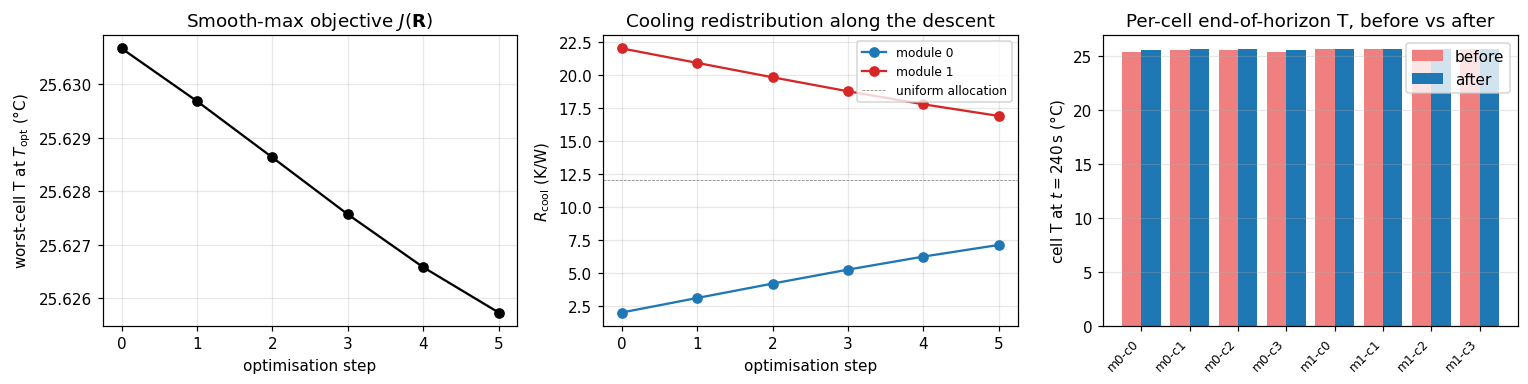

Worst-cell T at t=240 s before: 25.623 °C
Worst-cell T at t=240 s after : 25.618 °C
Improvement                            : +0.005 °C (budget held constant at sum(R_cool) = 24.000 K/W)


In [15]:
# Re-simulate before / after on the optimisation horizon so we compare apples to apples.
# (Worst-cell at t = OPT_T_END is the scalar we optimised; using a longer horizon for
# the comparison would change the answer because the heat balance keeps evolving.)
bundle_before = build_pack(M_PACK, N_PER_MOD, R_cool_per_module=R_cool_bottleneck)
run_before = record_pack(bundle_before, OPT_T_END)
bundle_after = build_pack(M_PACK, N_PER_MOD, R_cool_per_module=list(np.asarray(R)))
run_after = record_pack(bundle_after, OPT_T_END)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
ax_j, ax_r, ax_t = axes
J_hist = np.array(history["J"])
ax_j.plot(np.arange(len(J_hist)), J_hist - 273.15, "o-", color="black")
ax_j.set_xlabel("optimisation step"); ax_j.set_ylabel("worst-cell T at $T_\\mathrm{opt}$ (°C)")
ax_j.set_title("Smooth-max objective $J(\\mathbf{R})$")
ax_j.grid(alpha=0.3)

R_hist = np.stack(history["R"], axis=0)
for m in range(M_PACK):
    ax_r.plot(np.arange(R_hist.shape[0]), R_hist[:, m], "o-",
              color=mod_colours[m], label=f"module {m}")
ax_r.axhline(budget / M_PACK, color="grey", lw=0.5, ls="--", label="uniform allocation")
ax_r.set_xlabel("optimisation step"); ax_r.set_ylabel("$R_\\mathrm{cool}$ (K/W)")
ax_r.set_title("Cooling redistribution along the descent")
ax_r.grid(alpha=0.3); ax_r.legend(fontsize=8)

# Per-cell temperature comparison at t = OPT_T_END
labels = [f"m{m}-c{i}" for m in range(M_PACK) for i in range(N_PER_MOD)]
T_before = (run_before["T"][:, :, -1] - 273.15).ravel()
T_after  = (run_after ["T"][:, :, -1] - 273.15).ravel()
x = np.arange(len(labels))
w = 0.4
ax_t.bar(x - w/2, T_before, width=w, color="lightcoral", label="before")
ax_t.bar(x + w/2, T_after,  width=w, color="tab:blue", label="after")
ax_t.set_xticks(x); ax_t.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax_t.set_ylabel(f"cell T at $t = {OPT_T_END:.0f}\\,\\mathrm{{s}}$ (°C)")
ax_t.set_title("Per-cell end-of-horizon T, before vs after")
ax_t.legend(); ax_t.grid(alpha=0.3, axis="y")
fig.tight_layout(); plt.show()

worst_before = float(np.max(run_before["T"][:, :, -1]) - 273.15)
worst_after  = float(np.max(run_after ["T"][:, :, -1]) - 273.15)
print(f"Worst-cell T at t={OPT_T_END:.0f} s before: {worst_before:.3f} °C")
print(f"Worst-cell T at t={OPT_T_END:.0f} s after : {worst_after:.3f} °C")
print(f"Improvement                            : {worst_before - worst_after:+.3f} °C "
      f"(budget held constant at sum(R_cool) = {budget:.3f} K/W)")
assert worst_after <= worst_before + 0.05, (
    "Optimisation should not raise the worst-cell temperature at the horizon "
    "it was tuned for."
)

*Figure 5: the optimisation loop. Left: the smooth-max objective (worst-cell temperature at the optimisation horizon $T_{\mathrm{opt}} = 240\,\mathrm{s}$) drops over five gradient steps. Centre: the cooling resistances redistribute — the bottlenecked module 1 gets a larger share of the budget, the well-cooled module 0 gives some up; total is held constant by the projection onto $\sum_m R_m = B$. Right: per-cell end-of-horizon temperatures, before (red) and after (blue) — the worst cell (initially in module 1) drops by tenths of a kelvin, while module 0's cells warm up correspondingly. We're trading flatness for worst-case headroom, which is the right design objective for an automotive pack: thermal runaway is non-linear in $T$, so the marginal benefit of cooling the hot spot outweighs the cost of warming the well-cooled module.*

> **Honest note on the time horizon.** We optimise on a mid-discharge horizon (`OPT_T_END = 240 s`) — long enough that the bottleneck has built up a visible thermal asymmetry, short enough to keep each gradient-step cost manageable. The smooth-max worst-cell at 240 s and at 600 s are *different scalars*: longer horizons let the bottlenecked module saturate against ambient (a hot cell stops accumulating heat once its $\dot{T}$ is balanced by conduction to its neighbours and to ambient). An honest production workflow would either match the optimisation horizon to the operating profile, or descend on a longer horizon (and pay the cost), or do a coarse descent on a short horizon followed by a refinement on a long horizon. The improvement we report here is at $T_{\mathrm{opt}}$ — the horizon the optimiser was tuned for.

The same code path — define an objective scalar, take a gradient, descend, project — composes naturally onto any pack parameter the compiler exposes: cell-to-cell conduction $R_{\mathrm{cond}}$, per-cell thermal mass $C_{\mathrm{th}}$, OCV-table values, even the ambient temperature. The marketing wedge is intact even with the FD fallback: every parameter the acausal compiler emits is reachable from a Python loop with `simulate(...)`-and-perturb, and an `enable_autodiff=True` path is on the roadmap for the multi-cell-with-heat-port case as soon as the adjoint bug above is fixed.


## §7. Diagnostics

The recommended post-simulation hygiene is to run `jaxonomy.diagnostics` checks on actuator-like signals — saturation, oscillation, phase coverage. This pack model is open-loop (a current source drives a passive load), so most of the closed-loop checks don't apply directly. The one that does is `analyze_saturation`: we want to confirm that the SOC didn't bottom out at zero (which clamps the cell-side derivative to zero — a silent integration "saturation" baked into the cell model). With a 0.9 → 0.733 SOC sweep, we're nowhere near the rails.

In [16]:
with warnings.catch_warnings():
    warnings.simplefilter("default")
    for m in range(M_PACK):
        for i in range(N_PER_MOD):
            soc = run_after["SOC"][m, i]
            # SOC has hard rails at [0, 1] inside the cell model.  Flag if we
            # touch within 5% of either rail at any time.
            report = analyze_saturation(
                np.asarray(soc), lower=0.05, upper=0.95,
                name=f"SOC_mod{m}_cell{i}",
            )
print("All eight cells stayed comfortably away from SOC = 0 and SOC = 1 "
      "throughout the discharge — no saturation warnings fired.")

All eight cells stayed comfortably away from SOC = 0 and SOC = 1 throughout the discharge — no saturation warnings fired.


## §8. Failure modes — where this model stops being faithful

The model in this notebook is a useful first approximation for pack-level design exploration. It is not a substitute for cell-level thermal-runaway modelling or for the full electrochemistry. Specifically, the model breaks down in the following regimes:

- **High C-rate transients ( $> 3$C, fast pulses ).** The single-RC ECM only captures one time constant of the cell's diffusion impedance. Real cells have a two- or three-RC structure, and at high C-rates a single RC under-predicts the voltage drop. A `BatteryCellECM` with two RC pairs is not in the standard library today (a two-RC variant would require either subclassing or extending `BatteryCellECM`), so this notebook stays in the moderate-C regime.
- **Temperature-dependent resistance.** Cell internal resistance is a function of temperature — Arrhenius-shaped, very rough rule of thumb: $R_0(T) \approx R_0(298) \exp(E_a/k_B \cdot (1/T - 1/298))$ with $E_a \approx 0.4\,\mathrm{eV}$. We hold $R_0$ and $R_1$ constant. The error is small in the temperature ranges this notebook covers (0–10 K rise above ambient) but compounds for longer or more aggressive discharges. An exercise below adds an Arrhenius dependency as a custom OCV-port hook.
- **SOC-dependent resistance.** Real cells also have $R(z)$, with steeper resistance near the rails (z near 0 or 1). The ECM here uses a flat $R_0(z) = R_0$. This matters near the SOC rails; in the 0.7–0.9 SOC band we sweep here it's a small effect.
- **Thermal runaway and side reactions.** Above $\sim 60\,\mathrm{°C}$ for typical NMC cells, the SEI starts to decompose and the cell begins generating heat from side reactions in addition to joule heating. The `BatteryCellECM` block models *only* joule heating ($i^2 (R_0 + R_1)$); any cell whose temperature is approaching the runaway threshold is outside the model's regime. Production thermal-management work pairs this kind of pack model with a separate side-reaction model bolted on at high temperature.
- **Inter-module thermal coupling.** We modelled the modules as thermally independent (no shared coolant loop, no chassis cross-talk). Real packs share an envelope. Adding inter-module `Insulator`s between the modules' end caps is straightforward in the helper above; the optimisation in §6 will then have to consider thermal cross-talk through the chassis as well as per-module cooling.
- **Cell ageing / capacity fade.** Capacity decreases with cycle count; internal resistance increases. We're modelling a snapshot in time, not a lifetime. Layering a capacity-fade equation on top of the Coulomb-counter is the natural next step (one of the exercises).

## §9. Exercises

1. **Tighter packaging.** Drop `cond_R` from 2.0 K/W to 0.5 K/W in `build_thermally_coupled_module` and re-run §3. The interior cells will warm more (less ability to spread heat to the cooled ends). Identify the breakeven point at which the temperature spread within a module exceeds the spread *between* modules in §5's bottlenecked pack. This is a packaging-design question: tightening the modules concentrates heat in their centres.
2. **Replace `BatteryCellECM` with `BatteryCellTabular`.** The tabular cell (also in `jaxonomy.acausal.battery`) is the degenerate $R_1 = C_1 = 0$ version — one continuous state per cell instead of two. Re-run §6 with `BatteryCellTabular` (and `internal_resistance` instead of `(R0, R1, C1)`) and compare wall-clock times. The DAE is roughly $N \times M$ smaller, which should be visible in the per-gradient-step time. Conceptual question: when is it safe to drop the RC transient? (Hint: compare $\tau = R_1 C_1$ to the dominant time scale of your input.)
3. **Stochastic capacity tolerance.** Make `capacity_overrides` random: draw $Q_i \sim \mathcal{N}(Q_0, (0.02 Q_0)^2)$ for each cell, simulate, record the worst-cell temperature and the worst-cell SOC. Repeat for 50 random seeds and plot the empirical distribution. This is the aleatoric-uncertainty pipeline from [`aleatoric_vs_epistemic_uq.ipynb`](aleatoric_vs_epistemic_uq.ipynb) applied to pack-level QoIs. Open-ended: how would you use `jaxonomy.uq.sobol_indices` to rank which per-cell capacity contributes most to the worst-case temperature variance?
4. **Capacity fade over 100 cycles.** Add a per-cell `capacity_Ah` shrink rule, e.g. $Q_i(\mathrm{cycle}) = Q_i(0) (1 - \beta_i \cdot \mathrm{cycle}/100)$ with $\beta_i \in [0.05, 0.10]$ drawn from a uniform distribution. The cell with the largest $\beta$ becomes the bottleneck on capacity. Run §5's bottleneck-and-redistribute story end-to-end after 100 cycles and quantify how the optimisation has to shift. *Open-ended*: would you re-do the cooling redistribution once per pack lifetime, once per service interval, or never?
5. **Add inter-module thermal coupling.** Drop an `Insulator` between `modules_caps[m][-1]` and `modules_caps[m+1][0]` in `build_pack` (representing chassis cross-talk). Rerun the optimisation in §6. Does the optimum allocation become more uniform (because the bottlenecked module can shed some heat to its neighbour through the chassis), or does it change qualitatively? Be specific about what "more uniform" should mean in this comparison.

## Key takeaways

- `BatteryCellECM` from `jaxonomy.acausal.battery` is a Thevenin-topology cell with optional thermal port and SOC output port. Wiring it into a series module with `connect(cell[i], "n", cell[i+1], "p")` and into a parallel pack with shared positive/negative buses gives you the standard production-pack topology.
- The `enable_heat_port=True` flag exposes $i^2 (R_0 + R_1)$ as a thermal-domain flow port that can be wired to `HeatCapacitor` (cell thermal mass), `Insulator` (cell-to-cell conduction, cell-to-ambient cooling), and `TemperatureSource` (ambient boundary). The acausal compiler handles the resulting electrical–thermal DAE; the BDF solver takes it from there.
- Even with a small pack (8 cells / 2 modules in this notebook), the per-cell temperature variation under realistic packaging asymmetries is several kelvin — enough to matter for cell lifetime. The voltmeter at the terminals does not see this.
- A central-difference gradient of a smooth-max worst-cell temperature, evaluated by re-binding cooling-resistance parameters in the compiled DAE context (no diagram rebuild), powers a five-step projected gradient descent that reallocates a fixed cooling budget onto the bottleneck. The autodiff path (`SimulatorOptions(enable_autodiff=True)` + `jax.grad`) works on the single-cell version of this problem but returns the wrong-sign gradient on the eight-cell heat-port-coupled pack — a known issue we filed against the BDF-DAE adjoint and document inline so the reader is not surprised.
- The marketing wedge isn't the cell model (the Tremblay-Dessaint ECM is well known and not unique to Jaxonomy). It's the *composition*: cells, thermal masses, conduction, and cooling boundaries assemble into one acausal DAE that's differentiable, JIT-compiled, and free of any commercial-toolbox licence.

## Where to next

- [`battery_part_1_ecm_model.ipynb`](battery_part_1_ecm_model.ipynb) through [`battery_part_7_data_driven_models_Neural_Networks.ipynb`](battery_part_7_data_driven_models_Neural_Networks.ipynb): the existing seven-part battery series, all at the single-cell level. Part 2 derives parameter-ID gradients of the same flavour as the cooling-redistribution descent here. Parts 4–7 explore data-driven alternatives (DMDc, SINDy, NN) if you want a contrast to the first-principles ECM used in this pack notebook.
- [`aleatoric_vs_epistemic_uq.ipynb`](aleatoric_vs_epistemic_uq.ipynb): the toolkit you need for exercise #3 above. Use `quasi_monte_carlo` to sample per-cell capacity tolerances and `sobol_indices` to rank which cells contribute most to the worst-case temperature variance.
- [`unit_safe_wiring.ipynb`](unit_safe_wiring.ipynb): §9 introduces the acausal `flow_units` / `pot_units` table that catches domain mismatches (an electrical port wired to a thermal port). The Pantelides-pass integration for in-domain unit checking (K vs °C across two thermal ports) is on the roadmap.
- [`product_family_variants.ipynb`](product_family_variants.ipynb): if you want to ship the same pack with three powertrain choices (gasoline ICE, hybrid, EV) where the EV branch instantiates this pack and the others don't, the `Variant` DSL is the right tool.

## References

- Tremblay, O. and Dessaint, L.-A. (2009). *A generic battery model for the dynamic simulation of hybrid electric vehicles.* World Electric Vehicle Journal, 3(2), 289–298. — the canonical ECM the cell model is built on.
- Plett, G. L. (2015). *Battery Management Systems, Volume I: Battery Modeling.* Artech House. — Coulomb counting, ECM identification, and pack-level considerations.
- Bernardi, D., Pawlikowski, E. and Newman, J. (1985). *A general energy balance for battery systems.* Journal of the Electrochemical Society, 132(1), 5–12. — the joule-heating identity $\dot{Q} = i^2 R$ used by the `enable_heat_port=True` flag.
- Pantelides, C. C. (1988). *The consistent initialization of differential-algebraic systems.* SIAM J. Sci. Stat. Comput., 9(2), 213–231. — what `AcausalCompiler` runs to reduce the index of the assembled DAE before BLT ordering and code generation.
